In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score, accuracy_score, confusion_matrix
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder

In [ ]:
df = pd.read_csv('heart_disease_prediction_raw.csv')
df.sample(5)

,id,age,gender,chest_pain_type,resting_bp,cholesterol,fasting_blood_sugar,resting_ecg,max_heart_rate,exercise_angina,oldpeak,slope,thal,heart_disease
32946,20304.0,90.0,F,NaN,126.0,524.000000,1.0,Normal,103.0,Yes,NaN,NaN,Normal,1.0
32425,28878.0,71.0,Male,Atypical Angina,184.0,1070.626481,1.0,Left Ventricular Hypertrophy,193.0,Yes,0.6,Upsloping,Fixed Defect,1.0
14485,53049.0,80.0,MALE,Non-Anginal Pain,132.0,337.000000,1.0,NaN,66.0,YES,4.5,upsloping,Fixed Defect,1.0
1164,NaN,84.0,Male,NaN,91.0,588.000000,1.0,Left Ventricular Hypertrophy,191.0,No,0.7,U,Normal,1.0
33887,20378.0,30.0,Male,Atypical Angina,102.0,178.000000,0.0,Left Ventricular Hypertrophy,188.0,N,0.6,Upsloping,Fixed Defect,0.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59289 entries, 0 to 59288
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   56381 non-null  float64
 1   age                  56384 non-null  float64
 2   gender               56325 non-null  object 
 3   chest_pain_type      56325 non-null  object 
 4   resting_bp           56376 non-null  float64
 5   cholesterol          56388 non-null  float64
 6   fasting_blood_sugar  56370 non-null  float64
 7   resting_ecg          56325 non-null  object 
 8   max_heart_rate       56388 non-null  float64
 9   exercise_angina      56325 non-null  object 
 10  oldpeak              56367 non-null  float64
 11  slope                56325 non-null  object 
 12  thal                 56325 non-null  object 
 13  heart_disease        56388 non-null  float64
dtypes: float64(8), object(6)
memory usage: 6.3+ MB


In [ ]:
#Finding the number of duplicate rows in the dataset
df.duplicated().sum()

np.int64(158)

In [ ]:
#removing duplicate rows
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

In [ ]:
#Finding the number of missing values in each column
df.isnull().sum()

id                     2907
age                    2905
gender                 2964
chest_pain_type        2964
resting_bp             2913
cholesterol            2900
fasting_blood_sugar    2919
resting_ecg            2964
max_heart_rate         2901
exercise_angina        2964
oldpeak                2921
slope                  2964
thal                   2963
heart_disease          2901
dtype: int64

In [ ]:
#dropping the 'id' column as it is not useful for analysis
df = df.drop(columns=['id'])

#drppping missing values in the 'heart_disease' column as it is the target variable and we cannot impute it
df = df.dropna(subset=['heart_disease'])
df.head()

,age,gender,chest_pain_type,resting_bp,cholesterol,fasting_blood_sugar,resting_ecg,max_heart_rate,exercise_angina,oldpeak,slope,thal,heart_disease
0,19.0,MALE,Non-Anginal Pain,138.0,1070.626481,1.0,Left Ventricular Hypertrophy,192.0,No,6.4,Downsloping,Reversible Defect,1.0
1,68.0,MALE,Asymptomatic,164.0,279.000000,1.0,Normal,86.0,Yes,6.2,Downsloping,Normal,1.0
2,30.0,Female,ASYMPTOMATIC,141.0,234.000000,0.0,Normal,175.0,NO,3.9,Upsloping,Normal,0.0
3,24.0,Female,Atypical Angina,NaN,389.000000,1.0,Left Ventricular Hypertrophy,164.0,No,0.9,NaN,NaN,0.0
4,23.0,Female,Typical Angina,199.0,372.000000,NaN,Left Ventricular Hypertrophy,127.0,No,3.6,D,Reversible Defect,1.0


In [ ]:
categorical_features = df.select_dtypes(include=['object']).columns
for col in categorical_features:
    print(f"Unique values in '{col}': {df[col].unique()}")

Unique values in 'gender': ['MALE' 'Female' 'Male' 'FEMALE' nan 'Female ' ' Male' 'M' 'Male ' 'F'
 'male' ' Female' 'female']
Unique values in 'chest_pain_type': ['Non-Anginal Pain' 'Asymptomatic' 'ASYMPTOMATIC' 'Atypical Angina'
 'Typical Angina' nan 'Asymptomatic ' 'typical angina' 'A' 'N'
 ' Asymptomatic' ' Typical Angina' 'ATYPICAL ANGINA' 'T'
 'NON-ANGINAL PAIN' 'Non-anginal pain' ' Non-Anginal Pain' 'asymptomatic'
 'Typical Angina ' 'Atypical angina' 'Non-Anginal Pain ' 'atypical angina'
 'Typical angina' 'TYPICAL ANGINA' 'Atypical Angina ' 'non-anginal pain'
 ' Atypical Angina']
Unique values in 'resting_ecg': ['Left Ventricular Hypertrophy' 'Normal' 'ST-T Wave Abnormality'
 'left ventricular hypertrophy' 'st-t wave abnormality' 'normal' nan
 'Left Ventricular Hypertrophy ' 'LEFT VENTRICULAR HYPERTROPHY'
 'ST-T Wave Abnormality ' 'L' 'NORMAL' ' ST-T Wave Abnormality' 'S'
 ' Left Ventricular Hypertrophy' 'St-t wave abnormality'
 'Left ventricular hypertrophy' 'ST-T WAVE ABNORMALI

In [ ]:
for col in categorical_features:
    df[col] = df[col].str.strip().str.lower()
    df[col] = df[col].replace('nan', np.nan)

for col in categorical_features:
    print(f"Unique values in '{col}': {df[col].unique()}")



Unique values in 'gender': ['male' 'female' nan 'm' 'f']
Unique values in 'chest_pain_type': ['non-anginal pain' 'asymptomatic' 'atypical angina' 'typical angina' nan
 'a' 'n' 't']
Unique values in 'resting_ecg': ['left ventricular hypertrophy' 'normal' 'st-t wave abnormality' nan 'l'
 's' 'n']
Unique values in 'exercise_angina': ['no' 'yes' nan 'y' 'n']
Unique values in 'slope': ['downsloping' 'upsloping' nan 'd' 'flat' 'u' 'f']
Unique values in 'thal': ['reversible defect' 'normal' nan 'fixed defect' 'f' 'n' 'r']


In [ ]:
df['gender'] = df['gender'].replace({'m': 'male','f': 'female'})
df['chest_pain_type'] = df['chest_pain_type'].replace({'a': 'asymptomatic','n': 'non-anginal pain','t': 'typical angina'})
df['resting_ecg'] = df['resting_ecg'].replace({'l': 'left ventricular hypertrophy','s': 'st-t wave abnormality','n': 'normal'})
df['exercise_angina'] = df['exercise_angina'].replace({'y': 'yes','n': 'no'})
df['slope'] = df['slope'].replace({'u': 'upsloping','d': 'downsloping','f': 'flat'})
df['thal'] = df['thal'].replace({'n': 'normal','f': 'fixed defect','r': 'reversible defect'})

for col in categorical_features:
    print(f"Unique values in '{col}': {df[col].unique()}")

Unique values in 'gender': ['male' 'female' nan]
Unique values in 'chest_pain_type': ['non-anginal pain' 'asymptomatic' 'atypical angina' 'typical angina' nan]
Unique values in 'resting_ecg': ['left ventricular hypertrophy' 'normal' 'st-t wave abnormality' nan]
Unique values in 'exercise_angina': ['no' 'yes' nan]
Unique values in 'slope': ['downsloping' 'upsloping' nan 'flat']
Unique values in 'thal': ['reversible defect' 'normal' nan 'fixed defect']


In [ ]:
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        df[col] = df[col].fillna(df[col].median())

df = df[df['heart_disease'].isin([0, 1])]

for col in ['age','resting_bp','cholesterol','fasting_blood_sugar','max_heart_rate','heart_disease']:
    df[col] = df[col].astype(int)
df.sample(5)

,age,gender,chest_pain_type,resting_bp,cholesterol,fasting_blood_sugar,resting_ecg,max_heart_rate,exercise_angina,oldpeak,slope,thal,heart_disease
31620,83,female,typical angina,164,295,1,st-t wave abnormality,125,yes,2.6,upsloping,normal,1
15707,20,male,typical angina,145,1070,1,normal,101,yes,3.9,downsloping,fixed defect,1
51986,89,female,atypical angina,80,272,0,st-t wave abnormality,68,yes,2.3,upsloping,reversible defect,1
4272,30,female,asymptomatic,157,599,0,normal,83,yes,2.5,downsloping,fixed defect,1
42479,85,female,non-anginal pain,117,145,0,st-t wave abnormality,88,no,6.0,upsloping,normal,0


In [ ]:
#missing values after imputation
df.isnull().sum()

age                    0
gender                 0
chest_pain_type        0
resting_bp             0
cholesterol            0
fasting_blood_sugar    0
resting_ecg            0
max_heart_rate         0
exercise_angina        0
oldpeak                0
slope                  0
thal                   0
heart_disease          0
dtype: int64

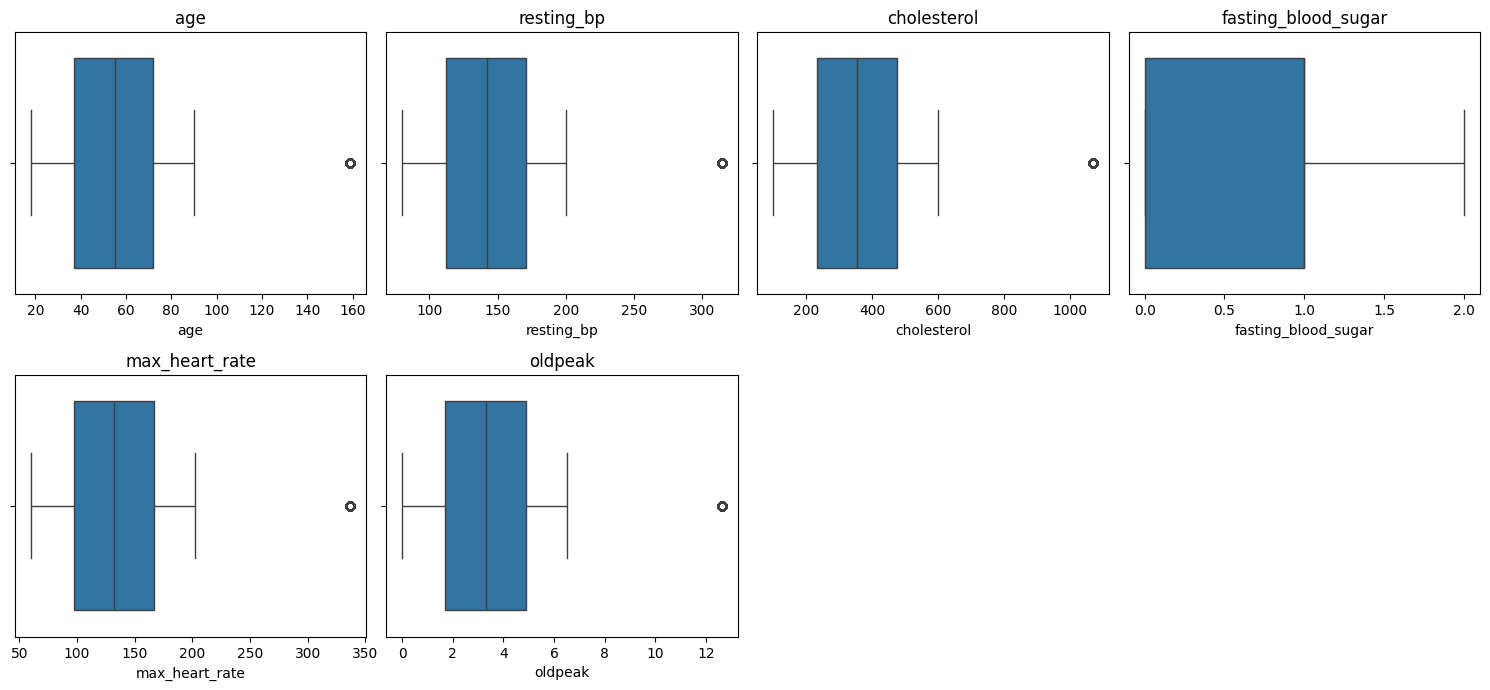

In [ ]:
target = df['heart_disease']
features = df.drop(columns=['heart_disease'])
continuous_features = features.select_dtypes(include=['int64', 'float64']).columns


#identifying outliers using boxplots
plt.figure(figsize=(15, 10))

for i, col in enumerate(continuous_features):
    plt.subplot(3, 4, i+1)  
    sns.boxplot(x=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

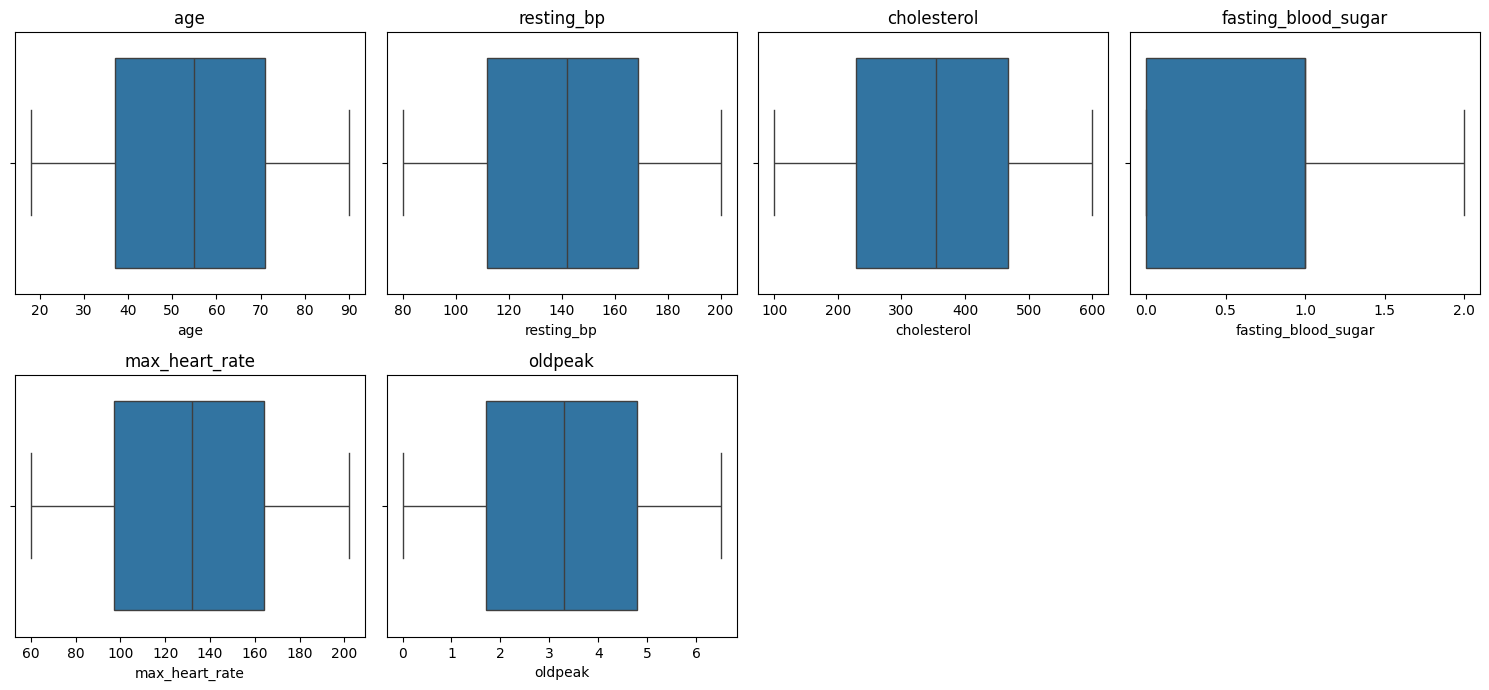

In [ ]:
#removing outliers using iqr
for col in continuous_features:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

plt.figure(figsize=(15, 10))

for i, col in enumerate(continuous_features):
    plt.subplot(3, 4, i+1)  
    sns.boxplot(x=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [ ]:
#exporting the cleaned dataset to a new csv file
df.to_csv('heart_disease_prediction_cleaned.csv', index=False)